Image path: E:\school\BrainInk-Local\test2.jpeg
Image size: (960, 1280)


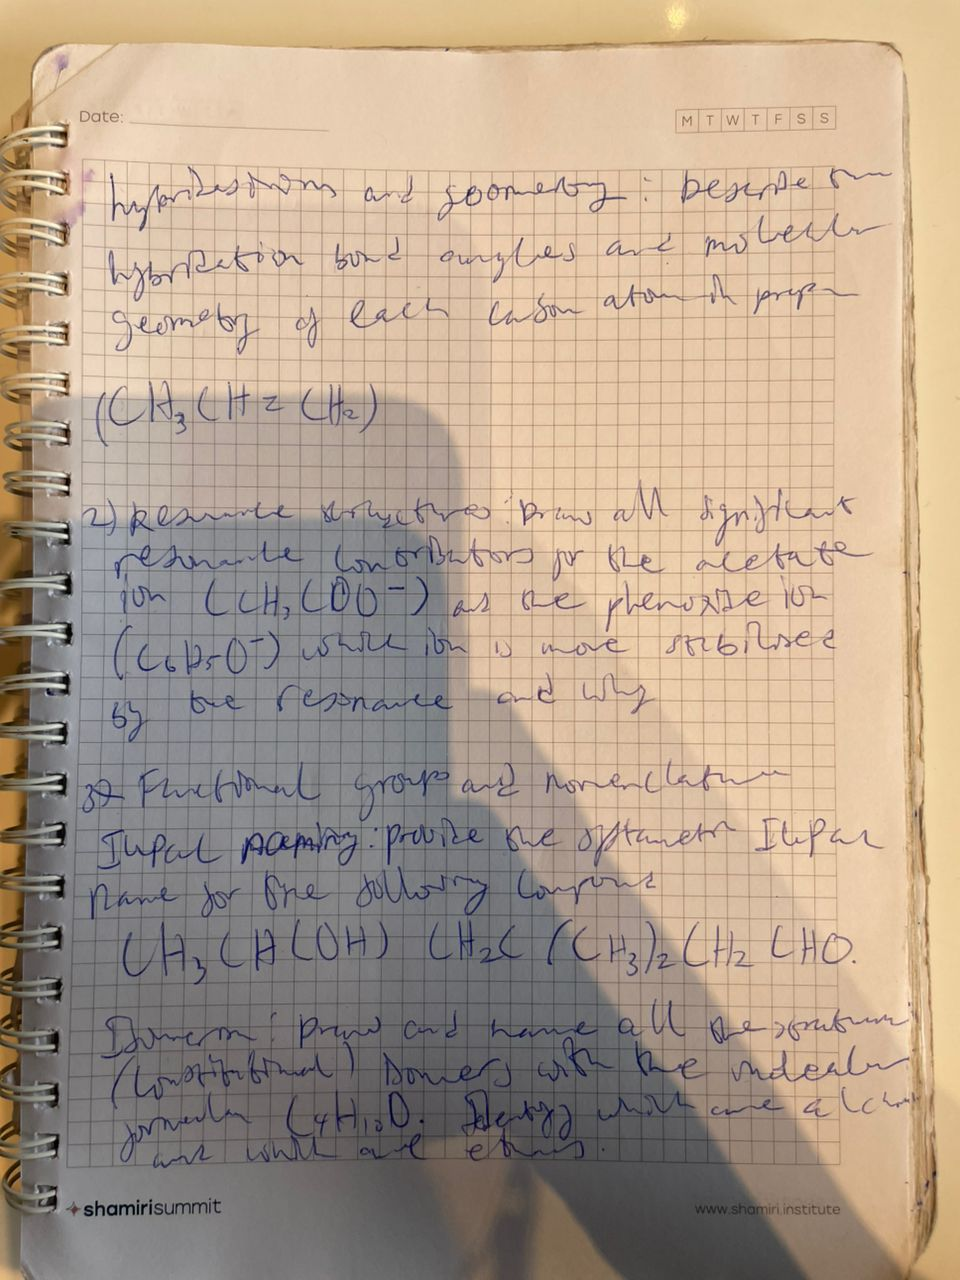

Tiling: 3x2 -> 6 tiles
  tile 01: box=(0, 0, 537, 478)
  tile 02: box=(423, 0, 960, 478)
  tile 03: box=(0, 376, 537, 905)
  tile 04: box=(423, 376, 960, 905)
  tile 05: box=(0, 803, 537, 1280)
  tile 06: box=(423, 803, 960, 1280)

Top CLIP matches over the WHOLE image (tiles aggregated):
- printed text       score=0.0287  best_tile=04  box=(423, 376, 960, 905)
- blank page         score=0.0287  best_tile=04  box=(423, 376, 960, 905)
- attendance sheet   score=0.0287  best_tile=05  box=(0, 803, 537, 1280)
- grade sheet        score=0.0286  best_tile=05  box=(0, 803, 537, 1280)
- school report card score=0.0286  best_tile=05  box=(0, 803, 537, 1280)
- document           score=0.0285  best_tile=04  box=(423, 376, 960, 905)
- report card        score=0.0284  best_tile=02  box=(423, 0, 960, 478)
- table              score=0.0284  best_tile=05  box=(0, 803, 537, 1280)
- form               score=0.0283  best_tile=04  box=(423, 376, 960, 905)
- spreadsheet        score=0.0283  best_tile=03  b

In [7]:
# CLIP smoke test on a real image (zero-shot label matching over the *whole* image)
# Note: CLIP does NOT do OCR or generate DocTags/captions; it returns embeddings.

# To cover the whole page (not just one 224x224 crop), we score labels over a grid of tiles
# and aggregate the scores.

import math
from typing import List, Tuple

import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(MODEL_ID)
clip_model = CLIPModel.from_pretrained(MODEL_ID).to(DEVICE)
clip_model.eval()

TEST_IMAGE_PATH = r"E:\school\BrainInk-Local\test2.jpeg"
real_img = Image.open(TEST_IMAGE_PATH).convert("RGB")

print("Image path:", TEST_IMAGE_PATH)
print("Image size:", real_img.size)

# Show the full image in notebook output (no matplotlib needed)
try:
    from IPython.display import display
    display(real_img)
except Exception as e:
    print("(Image display skipped)", type(e).__name__, str(e))


def make_grid_tiles(img: Image.Image, rows: int, cols: int, overlap: float = 0.10) -> List[Tuple[Image.Image, Tuple[int, int, int, int]]]:
    """Split an image into a rows x cols grid with optional overlap (fraction of tile size)."""
    w, h = img.size
    tile_w = math.ceil(w / cols)
    tile_h = math.ceil(h / rows)
    ox = int(tile_w * overlap)
    oy = int(tile_h * overlap)

    tiles: List[Tuple[Image.Image, Tuple[int, int, int, int]]] = []
    for r in range(rows):
        for c in range(cols):
            x1 = max(0, c * tile_w - ox)
            y1 = max(0, r * tile_h - oy)
            x2 = min(w, (c + 1) * tile_w + ox)
            y2 = min(h, (r + 1) * tile_h + oy)
            box = (x1, y1, x2, y2)
            tiles.append((img.crop(box), box))
    return tiles


# Choose a grid that covers a tall document well.
# For your report-card image, this will usually be 3x2 (6 tiles).
w, h = real_img.size
if h >= w * 1.15:
    GRID_ROWS, GRID_COLS = 3, 2
else:
    GRID_ROWS, GRID_COLS = 2, 3

tiles = make_grid_tiles(real_img, rows=GRID_ROWS, cols=GRID_COLS, overlap=0.12)
tile_images = [t[0] for t in tiles]
tile_boxes = [t[1] for t in tiles]

print(f"Tiling: {GRID_ROWS}x{GRID_COLS} -> {len(tile_images)} tiles")
for idx, box in enumerate(tile_boxes, start=1):
    print(f"  tile {idx:02d}: box={box}")

# A small label set tailored for documents/forms. Add/remove labels as needed.
LABELS = [
    "report card",
    "school report card",
    "grade sheet",
    "form",
    "document",
    "table",
    "spreadsheet",
    "certificate",
    "printed text",
    "logo",
    "attendance sheet",
    "blank page",
]

# Prompt templates often improve zero-shot behavior.
PROMPTS = [
    "a photo of a {}",
    "a scanned document of a {}",
    "a printed {}",
]
prompts = [tpl.format(lbl) for lbl in LABELS for tpl in PROMPTS]

with torch.no_grad():
    # Encode ALL tiles as a batch so CLIP covers the whole image
    image_inputs = clip_processor(images=tile_images, return_tensors="pt").to(DEVICE)
    image_feat = clip_model.get_image_features(**image_inputs)  # (T, 512)
    image_feat = torch.nn.functional.normalize(image_feat, p=2, dim=-1)

    # Encode text prompts once
    text_inputs = clip_processor(text=prompts, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
    text_feat = clip_model.get_text_features(**text_inputs)  # (N, 512)
    text_feat = torch.nn.functional.normalize(text_feat, p=2, dim=-1)

    # Similarity scores per tile: (T, N)
    sims = image_feat @ text_feat.T
    # Convert to probabilities per tile (softmax over prompts)
    probs = torch.softmax(sims, dim=1)

# Aggregate prompt variants back to labels by taking the max prob across:
# - prompt templates
# - tiles
label_scores = []
for i, lbl in enumerate(LABELS):
    start = i * len(PROMPTS)
    end = start + len(PROMPTS)
    per_tile = probs[:, start:end].max(dim=1).values  # (T,)
    best_tile_idx = int(torch.argmax(per_tile).detach().cpu())
    best_score = float(per_tile[best_tile_idx].detach().cpu())
    label_scores.append((lbl, best_score, best_tile_idx + 1, tile_boxes[best_tile_idx]))

label_scores.sort(key=lambda x: x[1], reverse=True)

print("\nTop CLIP matches over the WHOLE image (tiles aggregated):")
for lbl, score, tile_idx, box in label_scores[:10]:
    print(f"- {lbl:18s} score={score:.4f}  best_tile={tile_idx:02d}  box={box}")

print("\nReminder: this is label matching (not OCR).")

# Vision module (CLIP only)
This notebook contains **only** the CLIP vision-side code.

**Contract**
- Input: image of a handwritten exam answer (PIL image or file path)
- Output: CLIP image embedding tensor of shape **(B, 512)**

**Constraints**
- CLIP is used strictly as a vision encoder.
- CLIP does **not** grade, reason, or generate text.
- Downstream reasoning happens in `think.ipynb` via DistilBERT.

In [ ]:
import os
from typing import List, Optional, Union

import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

In [ ]:
class ClipVisionEncoder(torch.nn.Module):
    """CLIP vision encoder wrapper that returns a 512-d image embedding.

    Notes:
    - Uses Hugging Face `CLIPModel.get_image_features()` which runs:
        image -> vision transformer -> visual_projection -> (optionally) L2 norm
    - Does not load or use the text encoder for inference; the full CLIPModel is
      used only because it exposes the correct projection + feature method.
    """

    def __init__(
        self,
        model_name: str = "openai/clip-vit-base-patch32",
        device: Optional[str] = None,
        freeze: bool = True,
    ) -> None:
        super().__init__()
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model = CLIPModel.from_pretrained(model_name)
        self.model.to(self.device)

        if freeze:
            self.freeze()

    @torch.no_grad()
    def encode(
        self,
        images: Union[Image.Image, str, List[Union[Image.Image, str]]],
        normalize: bool = True,
    ) -> torch.Tensor:
        """Return image embeddings of shape (B, 512).

        Args:
            images: PIL image, file path, or list of either.
            normalize: if True, L2-normalize embeddings (common CLIP practice).
        """
        if not isinstance(images, list):
            images = [images]

        pil_images: List[Image.Image] = []
        for item in images:
            if isinstance(item, Image.Image):
                pil_images.append(item.convert("RGB"))
            elif isinstance(item, str):
                pil_images.append(Image.open(item).convert("RGB"))
            else:
                raise TypeError(f"Unsupported image type: {type(item)}")

        inputs = self.processor(images=pil_images, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(self.device)

        feats = self.model.get_image_features(pixel_values=pixel_values)
        # feats: (B, 512)
        if normalize:
            feats = torch.nn.functional.normalize(feats, p=2, dim=-1)
        return feats

    def freeze(self) -> None:
        self.model.eval()
        for p in self.model.parameters():
            p.requires_grad = False

    def unfreeze(self) -> None:
        self.model.train()
        for p in self.model.parameters():
            p.requires_grad = True


clip_encoder = ClipVisionEncoder(device=DEVICE, freeze=True)
clip_encoder

In [ ]:
# Demo: encode a single image path into (1, 512).
# Replace `EXAMPLE_IMAGE` with a real file path.
EXAMPLE_IMAGE = os.environ.get("EXAMPLE_IMAGE", "")

if EXAMPLE_IMAGE and os.path.exists(EXAMPLE_IMAGE):
    emb = clip_encoder.encode(EXAMPLE_IMAGE)
    print("embedding shape:", tuple(emb.shape))
    print("dtype/device:", emb.dtype, emb.device)
else:
    print("Set env var EXAMPLE_IMAGE to a valid image path to run this demo.")

## Hand-off to DistilBERT
The output embedding from CLIP is a tensor shaped `(B, 512)`.

Next steps happen in `think.ipynb`:
- A trainable projection maps `512 -> DistilBERT hidden_size (768)`
- The projected vector(s) are injected as **pseudo-token embeddings** into DistilBERT
- DistilBERT performs grading/classification/regression